In [ ]:
%pip install -r requirements.txt

/home/nipatiitti/projects/hackathons/junction2025/backend/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Run the Simulator with predictable target flowrate from 16_000 down to 0 over 96 timesteps
import numpy as np
import matplotlib.pyplot as plt
from simulation.simulator import Simulator

# Create input data for 96 time steps (24 hours, 15-minute intervals)
starting_water_level = 5.0  # meters

# Energy prices (constant for simplicity, can be varied)
energy_prices = [0.05] * 96  # EUR/kWh

# Water inflows (constant for simplicity)
water_inflows = [100.0] * 96  # m³/15min

# Target flowrates: linearly decreasing from 16000 to 0 over 96 timesteps
target_flowrates = np.linspace(16000 / 4, 0, 96).tolist()

# Create simulator
simulator = Simulator(
    starting_water_level=starting_water_level,
    energy_prices=energy_prices,
    water_inflows=water_inflows,
    target_flowrates=target_flowrates
)

# Run simulation
total_cost = simulator.simulate()

print(f"Total simulation cost: {total_cost:.2f} EUR")
print(f"Number of violations: {len(simulator.violations)}")
if simulator.violations:
    print("Violations:")
    for violation in simulator.violations[:5]:  # Show first 5
        print(f"  - {violation}")


Total simulation cost: 1458.82 EUR
Number of violations: 0


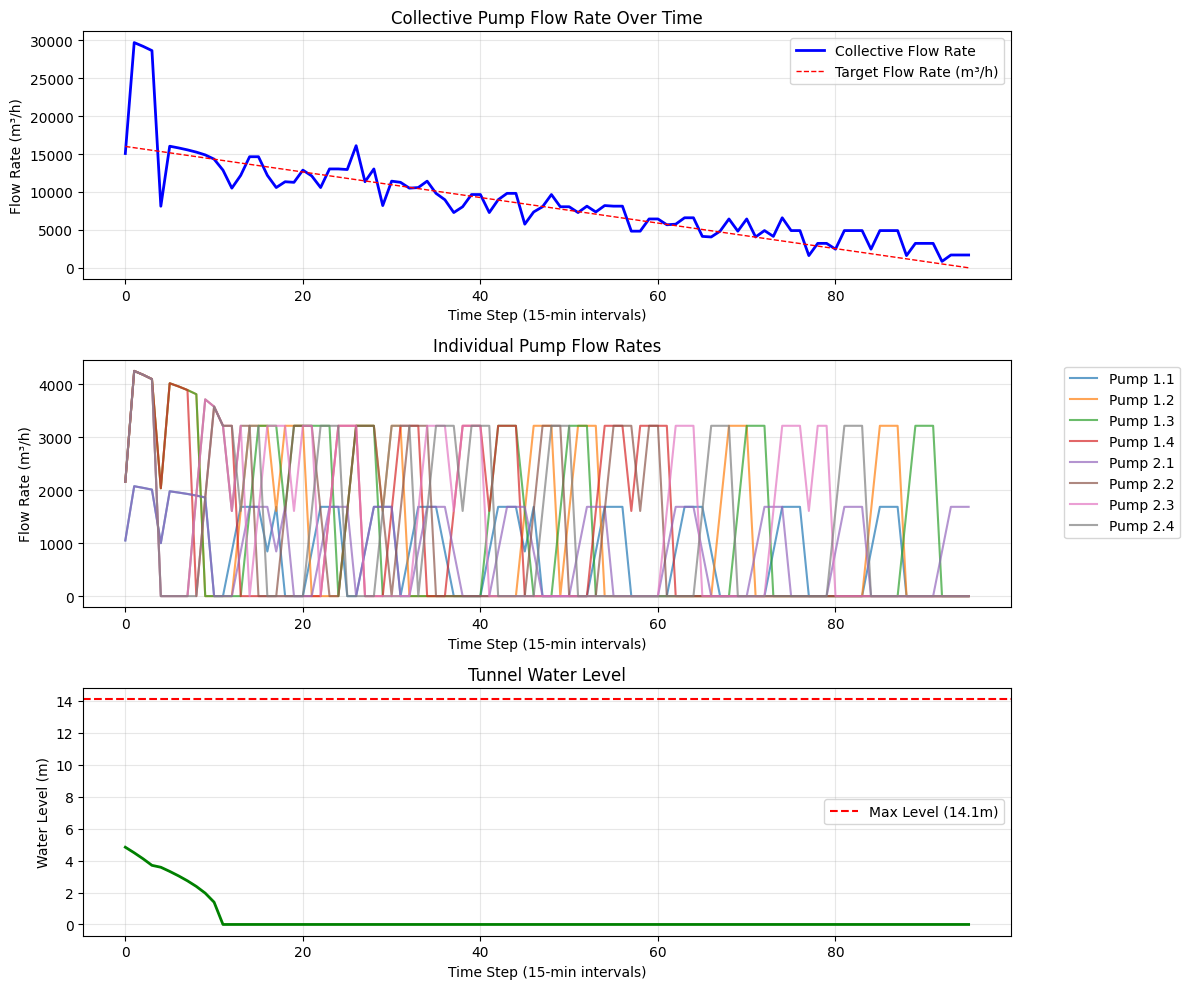


Flow Rate Statistics:
  Average collective flow: 8767.69 m³/h
  Max collective flow: 29691.05 m³/h
  Min collective flow: 843.81 m³/h

Pump Usage:
  Pump 1.1: 13.00 hours, Cost: 162.50 EUR
  Pump 1.2: 10.00 hours, Cost: 200.00 EUR
  Pump 1.3: 10.00 hours, Cost: 200.00 EUR
  Pump 1.4: 9.25 hours, Cost: 185.00 EUR
  Pump 2.1: 13.75 hours, Cost: 171.88 EUR
  Pump 2.2: 9.00 hours, Cost: 180.00 EUR
  Pump 2.3: 10.00 hours, Cost: 200.00 EUR
  Pump 2.4: 9.75 hours, Cost: 195.00 EUR


In [ ]:
# Plot collective flow rate of all pumps
time_steps = np.arange(96)

# Calculate collective flow rate (sum of all pump flows)
collective_flow = np.zeros(96)
for pump_id in simulator.pumps.keys():
    pump_flows = np.array(simulator.time_series_data["pump_flows"][pump_id])
    collective_flow += pump_flows

# Create figure with subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1: Collective flow rate
axes[0].plot(time_steps, collective_flow, 'b-', linewidth=2, label='Collective Flow Rate')
axes[0].plot(time_steps, np.array(target_flowrates) * 4, 'r--', linewidth=1, label='Target Flow Rate (m³/h)')
axes[0].set_xlabel('Time Step (15-min intervals)')
axes[0].set_ylabel('Flow Rate (m³/h)')
axes[0].set_title('Collective Pump Flow Rate Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Individual pump flows
for pump_id in sorted(simulator.pumps.keys()):
    pump_flows = simulator.time_series_data["pump_flows"][pump_id]
    axes[1].plot(time_steps, pump_flows, label=f'Pump {pump_id}', alpha=0.7)
axes[1].set_xlabel('Time Step (15-min intervals)')
axes[1].set_ylabel('Flow Rate (m³/h)')
axes[1].set_title('Individual Pump Flow Rates')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

# Plot 3: Water level
axes[2].plot(time_steps, simulator.time_series_data["water_levels"], 'g-', linewidth=2)
axes[2].axhline(y=14.1, color='r', linestyle='--', label='Max Level (14.1m)')
axes[2].set_xlabel('Time Step (15-min intervals)')
axes[2].set_ylabel('Water Level (m)')
axes[2].set_title('Tunnel Water Level')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nFlow Rate Statistics:")
print(f"  Average collective flow: {np.mean(collective_flow):.2f} m³/h")
print(f"  Max collective flow: {np.max(collective_flow):.2f} m³/h")
print(f"  Min collective flow: {np.min(collective_flow):.2f} m³/h")
print(f"\nPump Usage:")
for pump_id in sorted(simulator.pumps.keys()):
    usage_hours = simulator.pumps[pump_id].get_usage_time() / 60
    cost = simulator.pump_costs[pump_id]
    print(f"  Pump {pump_id}: {usage_hours:.2f} hours, Cost: {cost:.2f} EUR")
